In [ ]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error

In [ ]:
# Data Collection

path = "C:\\Users\\acer\\OneDrive\\Documents\\FADLAN IMAN\\TUGAS AKHIR\\data.xlsx"
df = pd.read_excel(path, "dataset")
df['Periode'] = pd.to_datetime(df['Periode'])
df = df.sort_values(by='Periode')
df.set_index('Periode', inplace=True)
X = df[['Kurs','Gold']]
y = X[['Gold']]

In [ ]:
# Data Normalization

scaler_X = MinMaxScaler(feature_range=(0,1))
scaler_y = MinMaxScaler(feature_range=(0,1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:
# Data Sequence

def create_sequence(X, y, n_steps):
    X_seq = []
    y_seq = []

    for i in range(len(X) - n_steps):
        
        X_seq.append(X[i:i+n_steps])        
        y_seq.append(y[i+n_steps])
    return np.array(X_seq), np.array(y_seq)

n_steps = 30

X, y = create_sequence(X_scaled, y_scaled, n_steps)

In [ ]:
#Data Split

train_size = int(len(X) * 0.7)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
# Variables

units = [10,50,100]
epochs = [50,100, 150]
batch_size_options = [16,32,64,128]

best_mae_train = float('inf')
best_mape_train = float('inf')
 
best_mae_test = float('inf')
best_mape_test = float('inf')

best_model = None
best_params = None
best_history = None

best_y_train_inv = None
best_y_pred_train_inv = None
best_y_test_inv = None
best_y_pred_test_inv = None 

results = []

In [ ]:
# Build Model
def build_model(params, X_train):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1:])))
    model.add(LSTM(units=params['units']))
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

In [ ]:
# Model Predict
def predict(model, X_train, X_test, y_train, y_test, scaler_y):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train = y_train.reshape(-1,1)
    y_test = y_test.reshape(-1,1) 

    y_train_inv = scaler_y.inverse_transform(y_train)
    y_test_inv = scaler_y.inverse_transform(y_test)

    y_pred_train_inv = scaler_y.inverse_transform(y_train_pred)
    y_pred_test_inv = scaler_y.inverse_transform(y_test_pred)

    return y_train_inv, y_pred_train_inv, y_test_inv ,y_pred_test_inv    

In [ ]:
# Model Evaluate
def evaluate(model, params, history, u, e, b, y_train_inv, y_pred_train_inv, y_test_inv, y_pred_test_inv, best_mae_train, best_mape_train, best_mae_test, best_mape_test, best_model, best_params, best_history,  best_y_train_inv, best_y_pred_train_inv, best_y_test_inv, best_y_pred_test_inv):
    mae_train = mean_absolute_error(y_train_inv, y_pred_train_inv)
    mae_test = mean_absolute_error(y_test_inv, y_pred_test_inv)

    mape_train = np.mean(np.abs((y_train_inv - y_pred_train_inv) / y_train_inv)) * 100
    mape_test = np.mean(np.abs((y_test_inv - y_pred_test_inv) / y_test_inv)) * 100
    
    results.append((u, e, b, mae_train, mape_train, mae_test, mape_test))
    if mape_test < best_mape_test:
        best_model = model
        best_params = params
        best_history = history

        best_mae_train = mae_train
        best_mape_train = mape_train
        best_mae_test = mae_test
        best_mape_test = mape_test

        best_y_train_inv = y_train_inv
        best_y_pred_train_inv = y_pred_train_inv
        best_y_test_inv = y_test_inv
        best_y_pred_test_inv = y_pred_test_inv
        
    return best_model, best_params, best_history, best_mae_train, best_mape_train,best_mae_test, best_mape_test, best_y_train_inv, best_y_pred_train_inv, best_y_test_inv, best_y_pred_test_inv


In [ ]:
# Graphic Visual
def plots(best_y_train_inv, best_y_pred_train_inv, best_y_test_inv, best_y_pred_test_inv):
    plt.plot(best_y_train_inv, label='Aktual Train')
    plt.plot(best_y_pred_train_inv, label='Predict Train')

    plt.plot(np.arange(len(best_y_train_inv), len(best_y_train_inv) + len(best_y_test_inv)), best_y_test_inv, label='Aktual Test')
    plt.plot(np.arange(len(best_y_train_inv), len(best_y_train_inv) + len(best_y_pred_test_inv)), best_y_pred_test_inv, label='Predict Test')

    plt.title('Grafik Prediksi Harga Emas')
    plt.legend()
    
    return plt.show()

In [ ]:
# Tunning Model
for u in units:

    for e in epochs: 

        for b in batch_size_options:
            print(f"Training with Unit: {u} Epoch: {e}, Batch Size: {b}")

            params = {'units': u, 'epochs': e, 'batch_size': b}

            model = build_model(params, X_train)

            history = model.fit(X_train, y_train, epochs=e, batch_size=b)

            y_train_inv, y_pred_train_inv,  y_test_inv, y_pred_test_inv = predict(model, X_train, X_test, y_train, y_test, scaler_y)
            
            best_model, best_params, best_history, best_mae_train, best_mape_train,best_mae_test, best_mape_test, best_y_train_inv, best_y_pred_train_inv, best_y_test_inv, best_y_pred_test_inv  = evaluate(model, params, history, u, e, b, y_train_inv, y_pred_train_inv, y_test_inv, y_pred_test_inv, best_mae_train, best_mape_train,  best_mae_test, best_mape_test,best_model, best_params,best_history, best_y_train_inv, best_y_pred_train_inv, best_y_test_inv, best_y_pred_test_inv)

Training with Unit: 10 Epoch: 50, Batch Size: 16
Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0363 - val_loss: 0.0946
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0400e-04 - val_loss: 0.0852
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.6663e-04 - val_loss: 0.0836
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.4444e-04 - val_loss: 0.0824
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8776e-04 - val_loss: 0.0812
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.6220e-04 - val_loss: 0.0789
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.5954e-04 - val_loss: 0.0750
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.3224e-04 - val_loss: 0.0733
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.4945e-04 - val_loss: 0.0728
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.8484e-04 - val_loss: 0.0706
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.3557e-04

Best Params: {'units': 100, 'epochs': 50, 'batch_size': 16} with MAE_TRAIN: 9316.1877 & MAPE_TRAIN: 0.8571% with MAE_TEST: 14594.5478 & MAPE_TEST: 0.8330%

Detailed results for each parameter combination:
Unit 10, Epoch: 50, Batch Size: 16 => MAE_TRAIN : 6413.7278 , MAPE_TRAIN : 0.5689%, MAE_TEST : 88479.3093 , MAPE_TEST : 4.7868%
Unit 10, Epoch: 50, Batch Size: 32 => MAE_TRAIN : 9490.7754 , MAPE_TRAIN : 0.8575%, MAE_TEST : 126778.2628 , MAPE_TEST : 6.9158%
Unit 10, Epoch: 50, Batch Size: 64 => MAE_TRAIN : 8882.1467 , MAPE_TRAIN : 0.7804%, MAE_TEST : 161019.0755 , MAPE_TEST : 8.8122%
Unit 10, Epoch: 50, Batch Size: 128 => MAE_TRAIN : 9661.6122 , MAPE_TRAIN : 0.8581%, MAE_TEST : 200316.2547 , MAPE_TEST : 11.0692%
Unit 10, Epoch: 100, Batch Size: 16 => MAE_TRAIN : 5749.9402 , MAPE_TRAIN : 0.5056%, MAE_TEST : 60846.4936 , MAPE_TEST : 3.3186%
Unit 10, Epoch: 100, Batch Size: 32 => MAE_TRAIN : 6672.0831 , MAPE_TRAIN : 0.5828%, MAE_TEST : 92271.9087 , MAPE_TEST : 5.0318%
Unit 10, Epoch: 100,

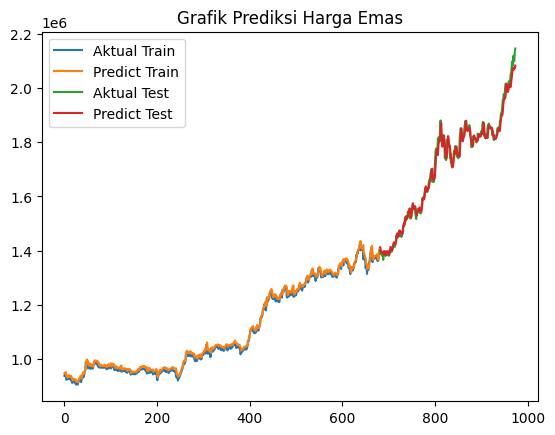

In [ ]:
# Evaluate Result
print(f"Best Params: {best_params} with MAE_TRAIN: {best_mae_train:.4f} & MAPE_TRAIN: {best_mape_train:.4f}% with MAE_TEST: {best_mae_test:.4f} & MAPE_TEST: {best_mape_test:.4f}%")
print("\nDetailed results for each parameter combination:")
for result in results:
    u, e, b, mae_train, mape_train, mae_test, mape_test = result
    print(f"Unit {u}, Epoch: {e}, Batch Size: {b} => MAE_TRAIN : {mae_train:.4f} , MAPE_TRAIN : {mape_train:.4f}%, MAE_TEST : {mae_test:.4f} , MAPE_TEST : {mape_test:.4f}%")

plots(best_y_train_inv, best_y_pred_train_inv, best_y_test_inv, best_y_pred_test_inv)

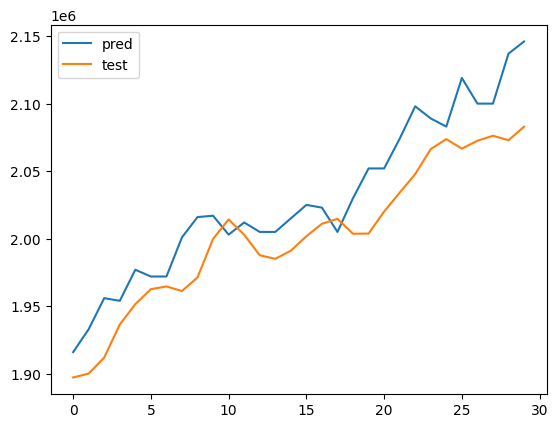

In [ ]:
# Model Saving
best_model.save("C:/Users/acer/OneDrive/Documents/FADLAN IMAN/TUGAS AKHIR/model_lstm_gold.keras")